# 600 Billboard Hot 100 Tracks (with Spotify Data)

- This dataset offers a comprehensive glimpse into the evolution of contemporary music, featuring 620 tracks from 87 artists who have dominated the charts between 2000 and 2023. Representing the pulse of modern pop and R&B, this collection captures the diversity and dynamism of the Hot 100 hits over the past two decades. Each track is meticulously annotated with Spotify's audio features, providing a rich, data-driven perspective on the sonic characteristics that have shaped the soundscape of the 21st century. From tempo to energy levels, and from danceability to valence, this dataset is a treasure trove for anyone looking to explore the trends and transformations in popular music.

## Columns Explanation

- **Track**: The title of the song
- **Artists**: The name of the performer or group
- **Album**: The album in which the track was released
- **Year**: The release year of the track
- **Duration**: The length of the track in milliseconds
- **Time_Signature**: The musical time signature (e.g., 4/4) of the track
- **Danceability**: A measure of how suitable the track is for dancing, ranging from 0 to 1
- **Energy**: A measure of the intensity and activity of the track, ranging from 0 to 1
- **Key**: The key in which the track is composed, represented as an integer (e.g., C=0, D=2)
- **Loudness**: The overall loudness of the track (dB)
- **Mode**: Indicates the modality of the track (0 for minor, 1 for major)
- **Speechiness**: A measure of the presence of spoken words in the track, ranging from 0 to 1
- **Acousticness**: A measure of the acoustic elements in the track, ranging from 0 to 1
- **Instrumentalness**: A measure of the presence of vocal versus instrumental elements, ranging from 0 to 1
- **Liveness**: A measure of the likelihood that the track was performed live, ranging from 0 to 1
- **Valence**: A measure of the musical positiveness conveyed by the track, ranging from 0 to 1
- **Tempo**: The speed of the track in beats per minute (BPM)
- **Popularity**: The popularity score of the track, as provided by Spotify, ranging from 0 to 100

## Project

### Configuration

- Mounting Drive

In [ ]:
from google.colab import drive
drive.mount("/content/gdrive")

#from google.colab import files
#files.upload()

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


- File path on Google Drive

In [ ]:
# Using drive.mount()
file_path = "/content/gdrive/MyDrive/Colab Notebooks/estatistica_probabilidade/Hot100.csv"

#Using files.upload()
#file_path = "/content/Hot100.csv"

- Imported required

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.figure_factory as ff
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats
from scipy.stats import norm

- Reading dataset

In [ ]:
billboard = pd.read_csv(file_path)

length_ds = len(billboard)
billboard.head()

,Track,Artist,Album,Year,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity
0,7 rings,Ariana Grande,"thank u, next",2019,178626,4,0.780,0.321,1,-10.747,0,0.3720,0.56200,0.000000,0.0881,0.315,139.961,50
1,Break Free,Ariana Grande,My Everything - Deluxe,2014,214840,4,0.686,0.702,7,-5.325,0,0.0455,0.00637,0.000045,0.2040,0.290,129.948,76
2,Dangerous Woman,Ariana Grande,Dangerous Woman,2016,235946,3,0.664,0.602,4,-5.369,0,0.0412,0.05290,0.000000,0.3560,0.289,134.049,70
3,God is a woman,Ariana Grande,Sweetener,2018,197546,4,0.602,0.658,1,-5.934,1,0.0558,0.02330,0.000060,0.2370,0.268,145.031,75
4,Into You,Ariana Grande,Dangerous Woman,2016,244453,4,0.623,0.734,9,-5.948,1,0.1070,0.01620,0.000002,0.1450,0.370,107.853,71


## Descriptive Statistics

### Box plot

In [ ]:
# plotly, bokeh, matoplotlib, seaborn, Altair, plotnine

#plotply.express

duration_plot = px.box(billboard, x='Duration', title="Box Plot of Duration in Milliseconds")

duration_plot.add_annotation(
    x=0.5,
    y=1.1,
    text="Note: 2000k ms = ~3:20min",
    showarrow=False,
    font=dict(size=12, color="black"),
    align="left"
)

duration_plot.update_layout(
    xaxis_title="ms",
     yaxis_title="Value"
)


duration_plot.show()


In [ ]:
tempo_plot = px.box(billboard, x='Tempo', title="Box Plot of Tempo in BPM")

tempo_plot.update_layout(
    xaxis_title="BPM",
     yaxis_title="Value"
)

tempo_plot.show()

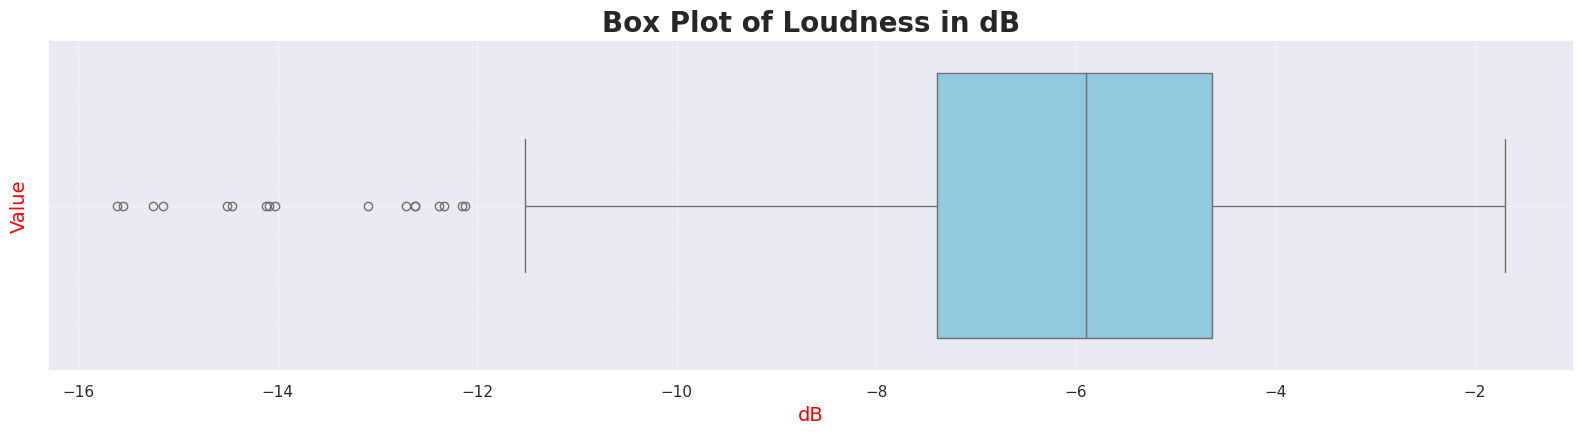

In [ ]:
# matplotlib.pyplot
# seaborn

sns.set(style="darkgrid")

plt.figure(figsize=(16, 8))

plt.subplot(2, 1, 2)
sns.boxplot(data=billboard, x="Loudness", color='skyblue')

plt.title("Box Plot of Loudness in dB", fontsize=20, fontweight='bold')
plt.xlabel("dB", fontsize=14, color='red')
plt.ylabel("Value", fontsize=14, color='red')

plt.grid(True, linestyle='--', linewidth=0.5)

plt.tight_layout()

plt.show()

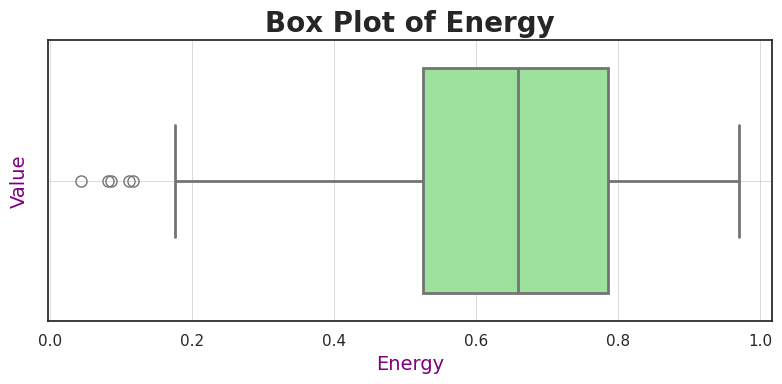

In [ ]:
sns.set(style="white")

plt.figure(figsize=(8, 4))

sns.boxplot(data=billboard, x="Energy", color='lightgreen', fliersize=8, linewidth=2)

plt.title("Box Plot of Energy", fontsize=20, fontweight='bold')
plt.xlabel("Energy", fontsize=14, color='purple')
plt.ylabel("Value", fontsize=14, color='purple')

plt.grid(True, linestyle='-', linewidth=0.5)

plt.tight_layout()

plt.show()


In [ ]:
loudness_plot = px.box(billboard, x='Popularity', title="Box Plot of Popularity")

loudness_plot.update_layout(
    xaxis_title="Popularity",
    yaxis_title="Value"
)

loudness_plot.show()

### Histogram

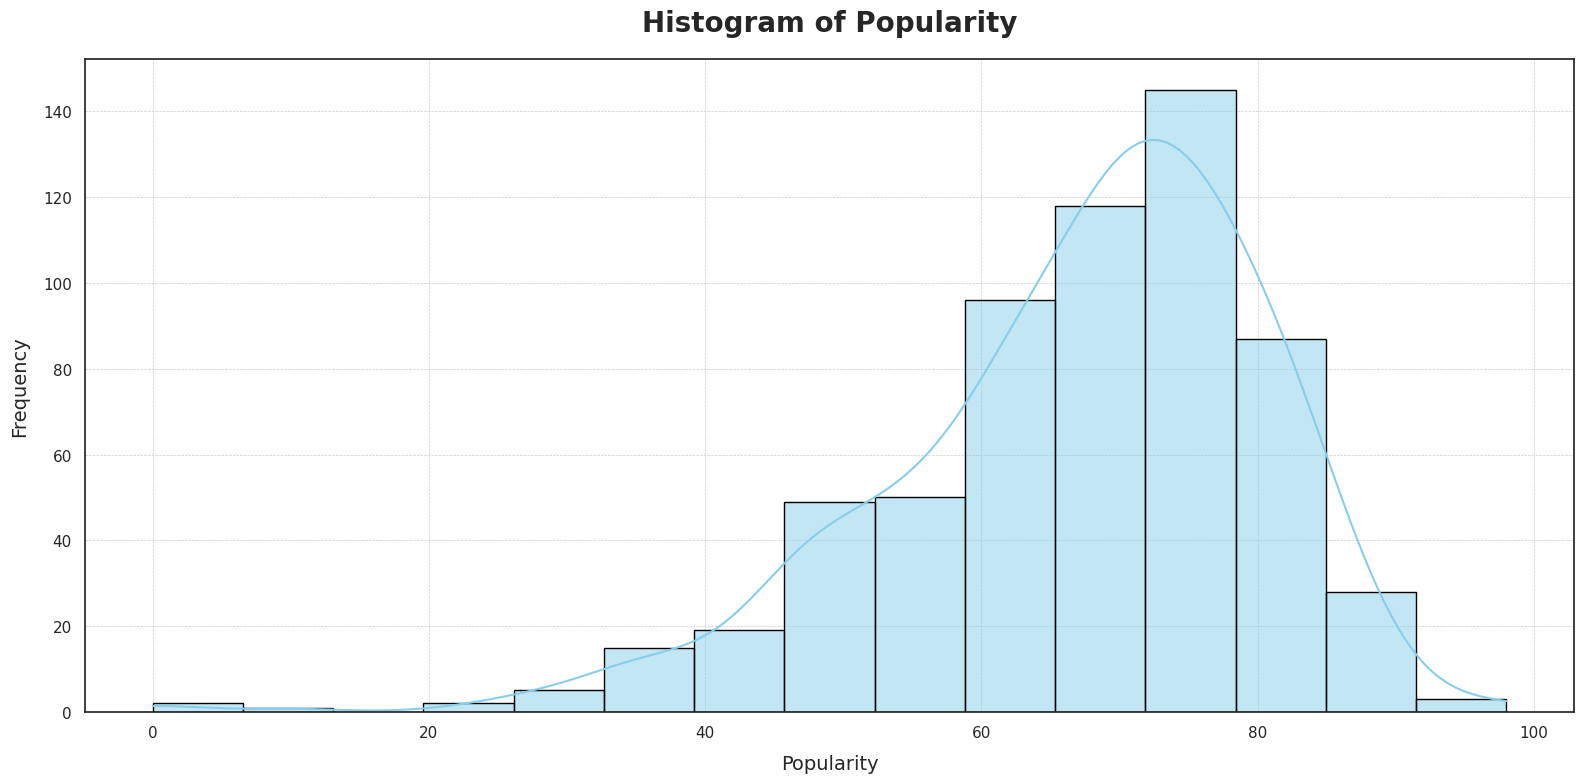

In [ ]:
plt.figure(figsize=(16, 8))

sns.histplot(
    billboard["Popularity"],
    bins=15,
    kde=True,
    color='skyblue',
    edgecolor='black'
).set_title("Histogram of Popularity", fontsize=20, fontweight='bold', pad=20)

plt.xlabel("Popularity", fontsize=14, labelpad=10)
plt.ylabel("Frequency", fontsize=14, labelpad=10)

plt.grid(True, linestyle='--', linewidth=0.5)

plt.tight_layout()

plt.show()


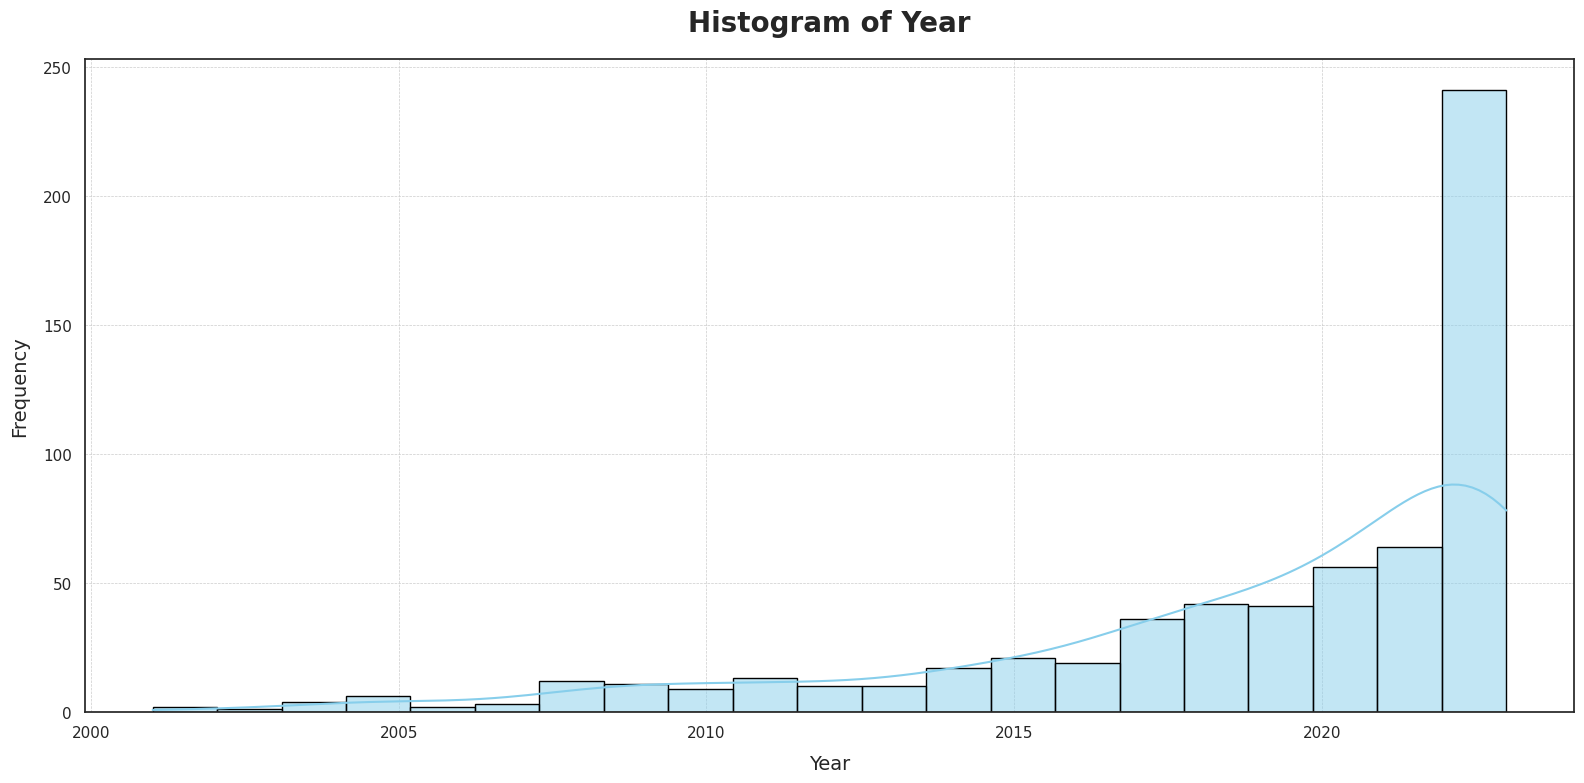

In [ ]:
plt.figure(figsize=(16, 8))

sns.histplot(
    billboard["Year"],
    bins=21,
    kde=True,
    color='skyblue',
    edgecolor='black'
).set_title("Histogram of Year", fontsize=20, fontweight='bold', pad=20)

plt.xlabel("Year", fontsize=14, labelpad=10)
plt.ylabel("Frequency", fontsize=14, labelpad=10)

plt.grid(True, linestyle='--', linewidth=0.5)

plt.tight_layout()

plt.show()


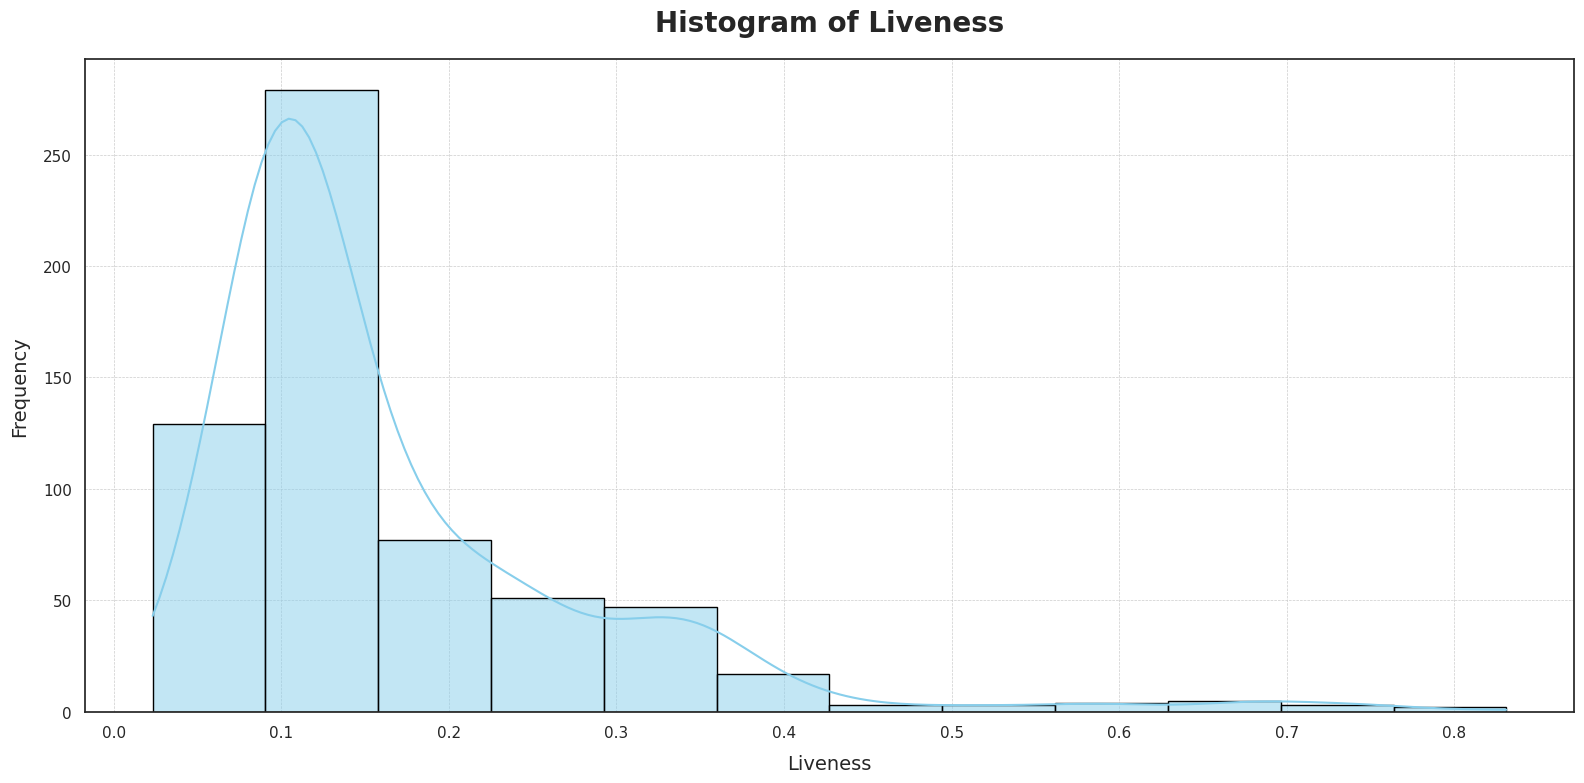

In [ ]:
plt.figure(figsize=(16, 8))

sns.histplot(
    billboard["Liveness"],
    bins=12,
    kde=True,
    color='skyblue',
    edgecolor='black'
).set_title("Histogram of Liveness", fontsize=20, fontweight='bold', pad=20)

plt.xlabel("Liveness", fontsize=14, labelpad=10)
plt.ylabel("Frequency", fontsize=14, labelpad=10)

plt.grid(True, linestyle='--', linewidth=0.5)

plt.tight_layout()

plt.show()


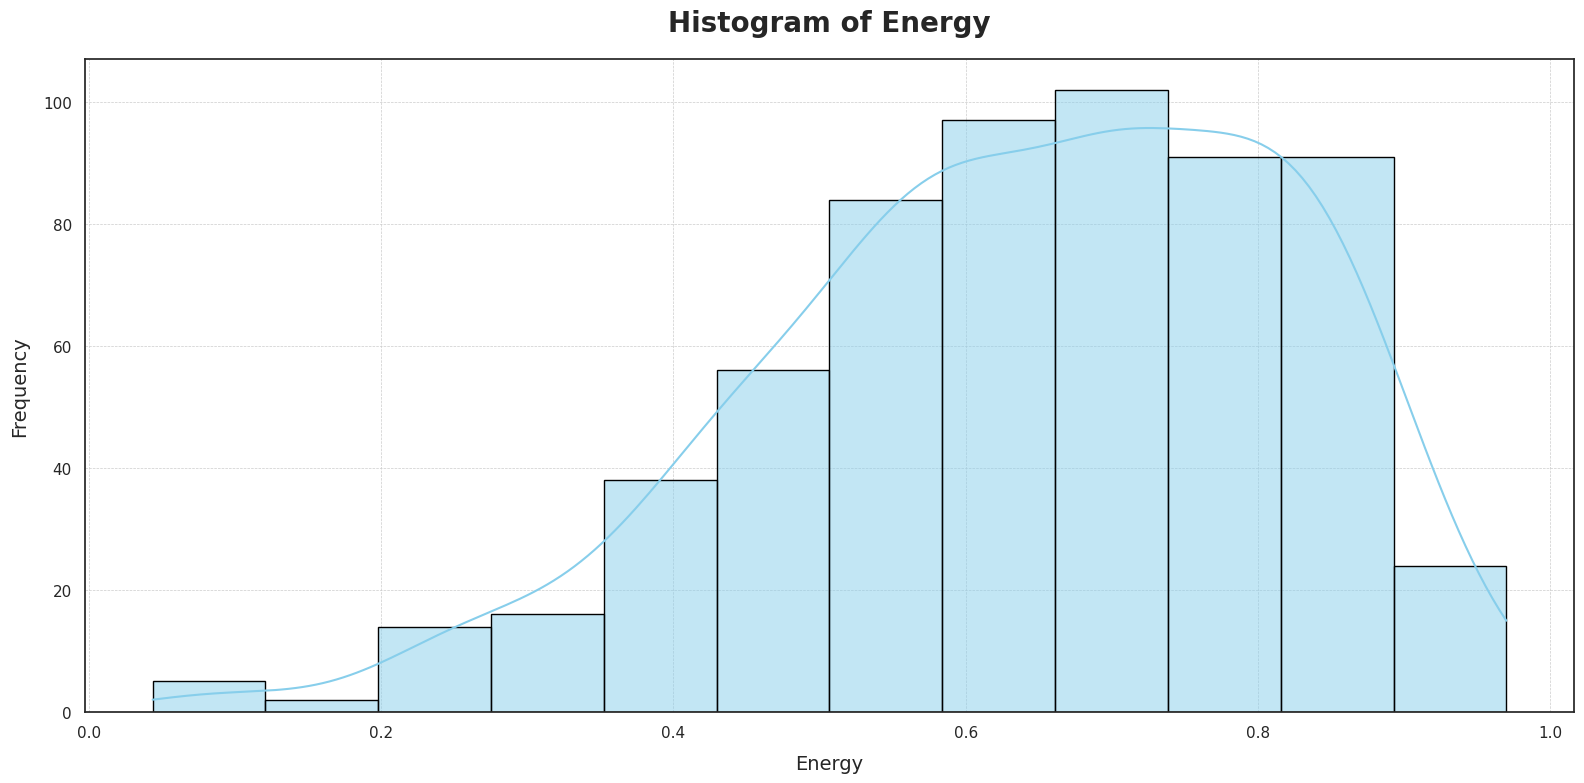

In [ ]:
plt.figure(figsize=(16, 8))

sns.histplot(
    billboard["Energy"],
    bins=12,
    kde=True,
    color='skyblue',
    edgecolor='black'
).set_title("Histogram of Energy", fontsize=20, fontweight='bold', pad=20)

plt.xlabel("Energy", fontsize=14, labelpad=10)
plt.ylabel("Frequency", fontsize=14, labelpad=10)

plt.grid(True, linestyle='--', linewidth=0.5)

plt.tight_layout()

plt.show()

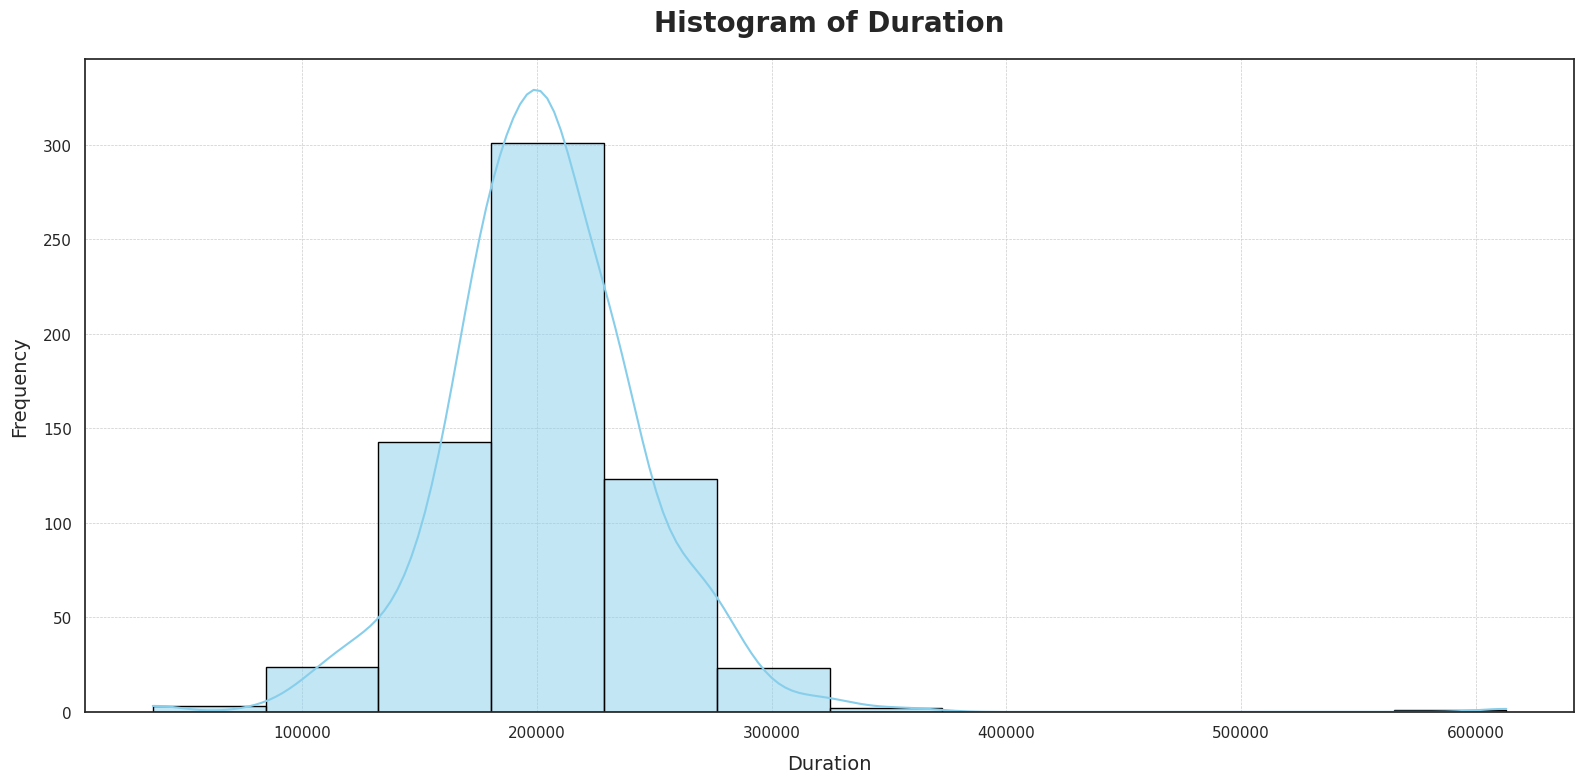

In [ ]:
plt.figure(figsize=(16, 8))

sns.histplot(
    billboard["Duration"],
    bins=12,
    kde=True,
    color='skyblue',
    edgecolor='black'
).set_title("Histogram of Duration", fontsize=20, fontweight='bold', pad=20)

plt.xlabel("Duration", fontsize=14, labelpad=10)
plt.ylabel("Frequency", fontsize=14, labelpad=10)

plt.grid(True, linestyle='--', linewidth=0.5)

plt.tight_layout()

plt.show()

### Scatter plot

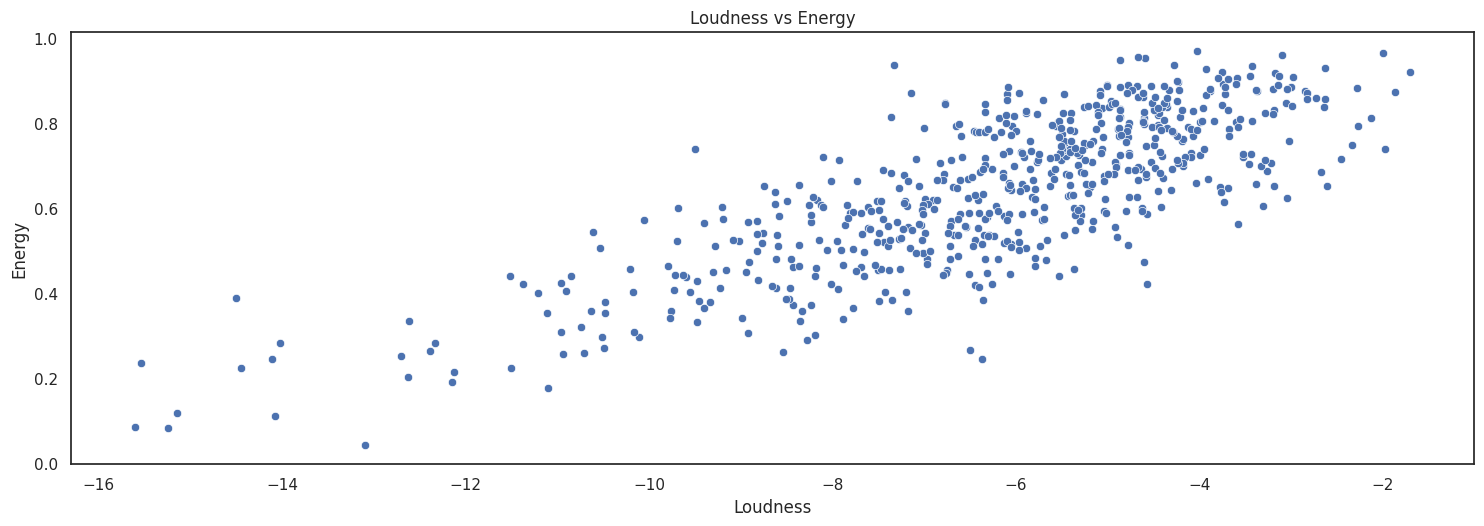

In [ ]:
plt.figure(figsize=(15, 25))

plt.subplot(5, 1, 1)
sns.scatterplot(data=billboard, x="Loudness", y="Energy").set_title("Loudness vs Energy")

plt.tight_layout()
plt.show()

In [ ]:
loudness_vs_popularity_plot = px.scatter(billboard, x="Danceability", y="Popularity", title="Danceability vs Popularity")

loudness_vs_popularity_plot.update_layout(xaxis_title="Danceability", yaxis_title="Popularity")

loudness_vs_popularity_plot.show()

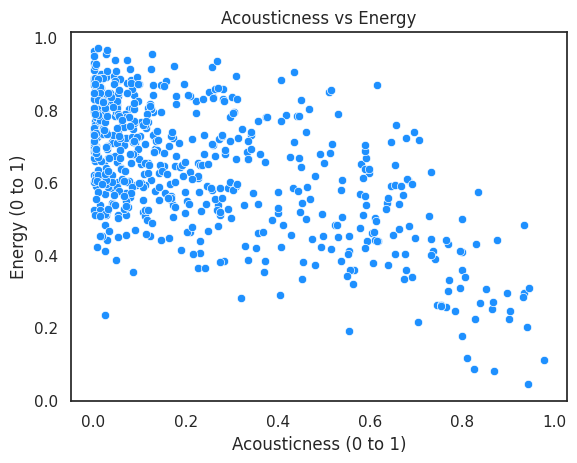

In [ ]:
sns.scatterplot(data=billboard, x="Acousticness", y="Energy", color='dodgerblue')

plt.title("Acousticness vs Energy")
plt.xlabel("Acousticness (0 to 1)")
plt.ylabel("Energy (0 to 1)")

plt.show()

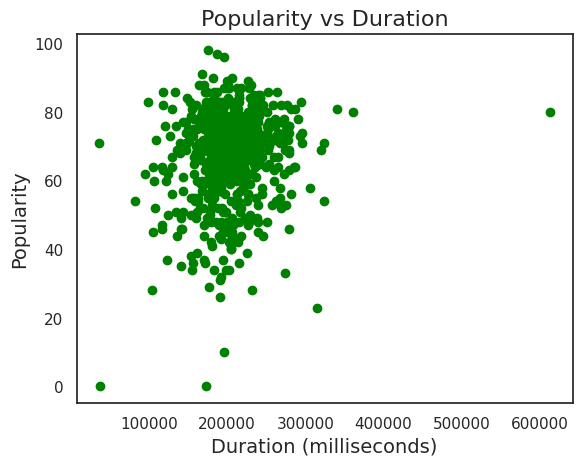

In [ ]:
plt.scatter(billboard['Duration'], billboard['Popularity'], color='green')

plt.title('Popularity vs Duration', fontsize=16)
plt.xlabel('Duration (milliseconds)', fontsize=14)
plt.ylabel('Popularity', fontsize=14)

plt.show()

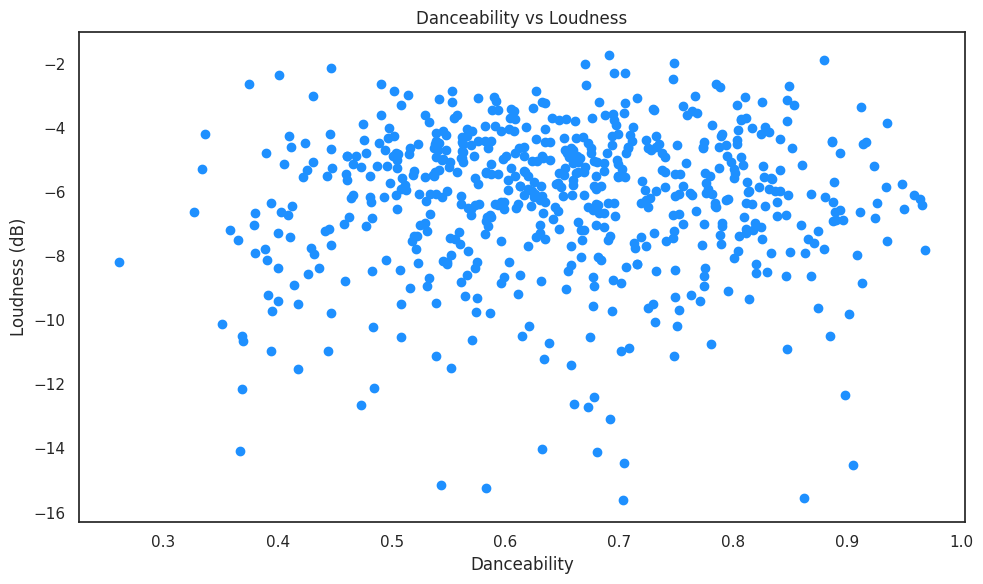

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(billboard['Danceability'], billboard['Loudness'], color='dodgerblue')

plt.title("Danceability vs Loudness")
plt.xlabel("Danceability")
plt.ylabel("Loudness (dB)")

plt.tight_layout()
plt.show()

### Heatmap for correlation

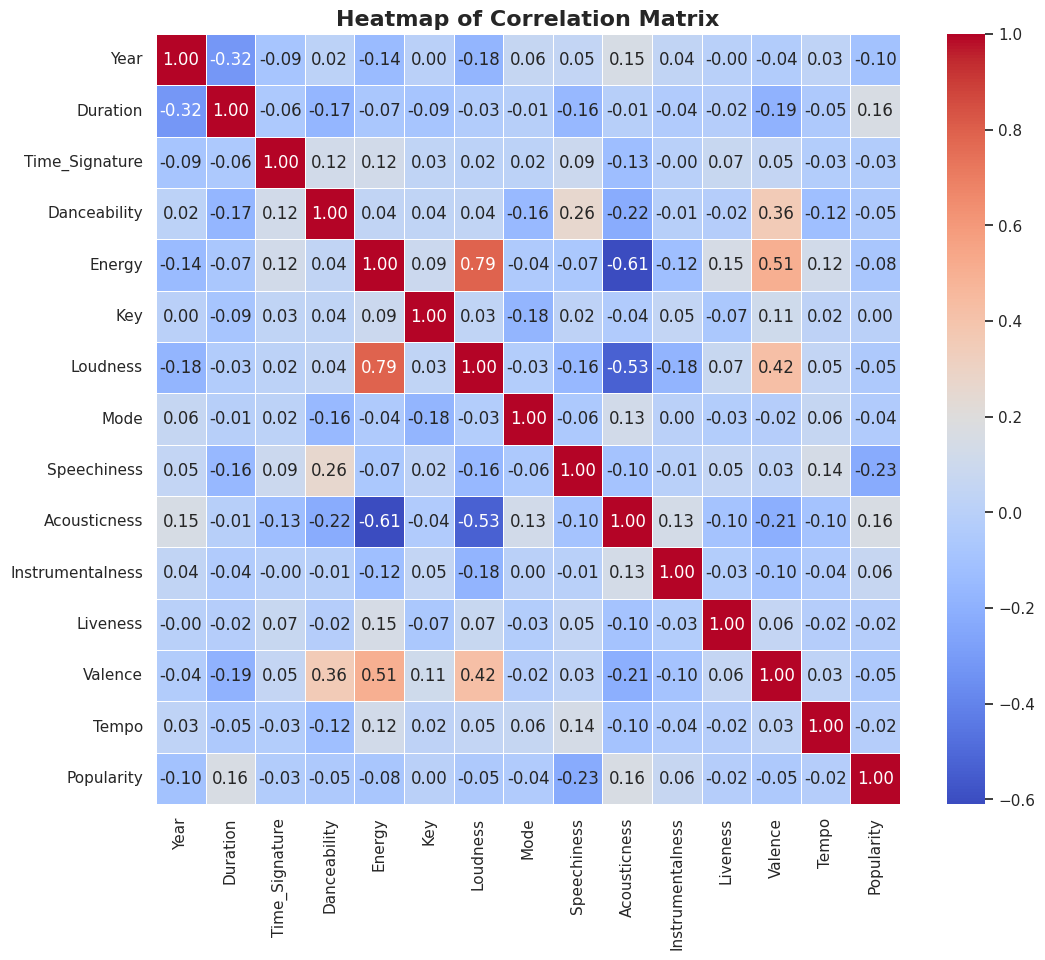

In [ ]:
numeric_columns = billboard.select_dtypes(include=[np.number])

correlation_matrix = numeric_columns.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Heatmap of Correlation Matrix", fontsize=16, weight='bold')

plt.show()

## Standard Normalization

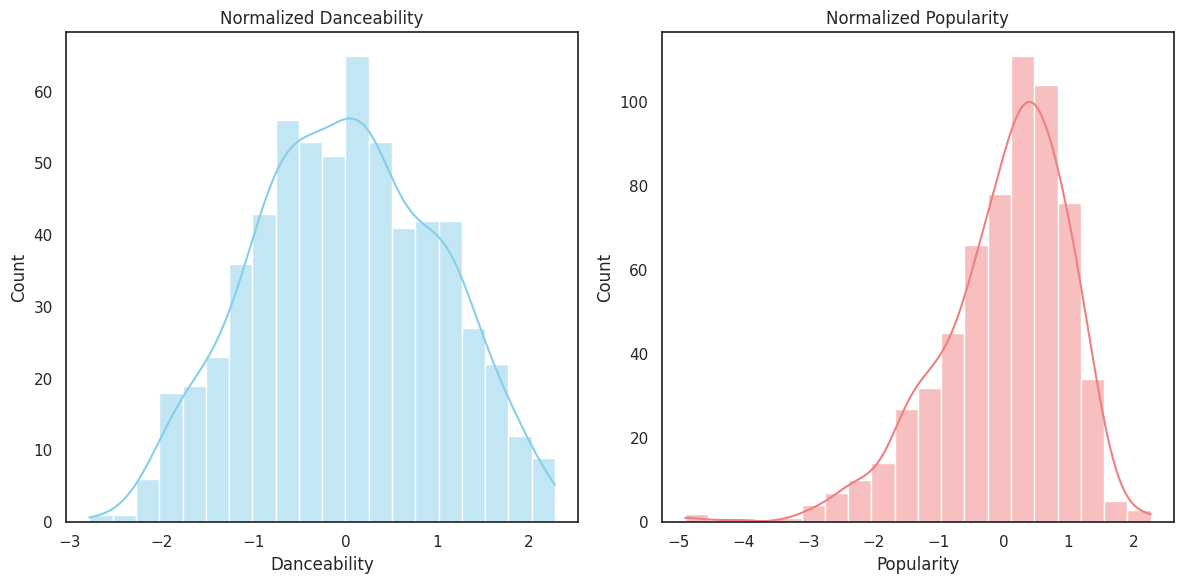

   Danceability  Popularity
0      0.933687   -1.240963
1      0.260147    0.658602
2      0.102510    0.220241
3     -0.341740    0.585542
4     -0.191268    0.293301


In [ ]:
columns_to_normalize = ['Danceability', 'Popularity']

scaler = StandardScaler()
normalized_data = scaler.fit_transform(billboard[columns_to_normalize])

normalized_df = pd.DataFrame(normalized_data, columns=columns_to_normalize)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(normalized_df['Danceability'], bins=20, kde=True, color='skyblue').set_title('Normalized Danceability')

plt.subplot(1, 2, 2)
sns.histplot(normalized_df['Popularity'], bins=20, kde=True, color='lightcoral').set_title('Normalized Popularity')

plt.tight_layout()

plt.show()

print(normalized_df.head())

## Sampling Distributions

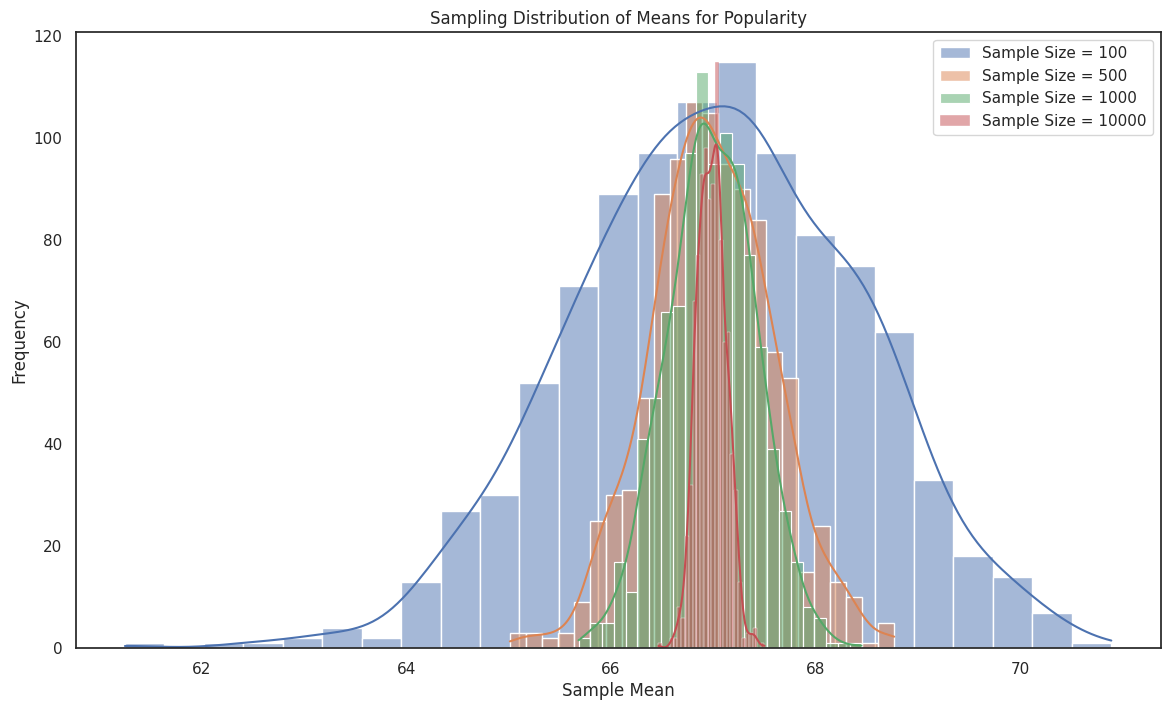

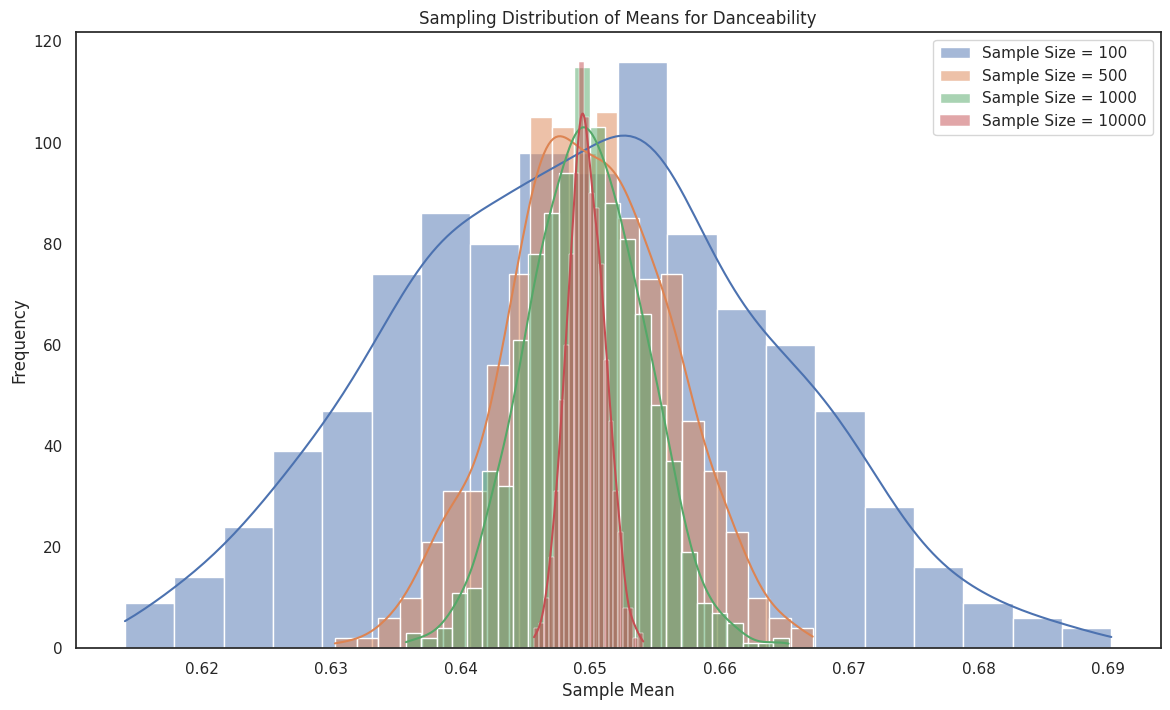

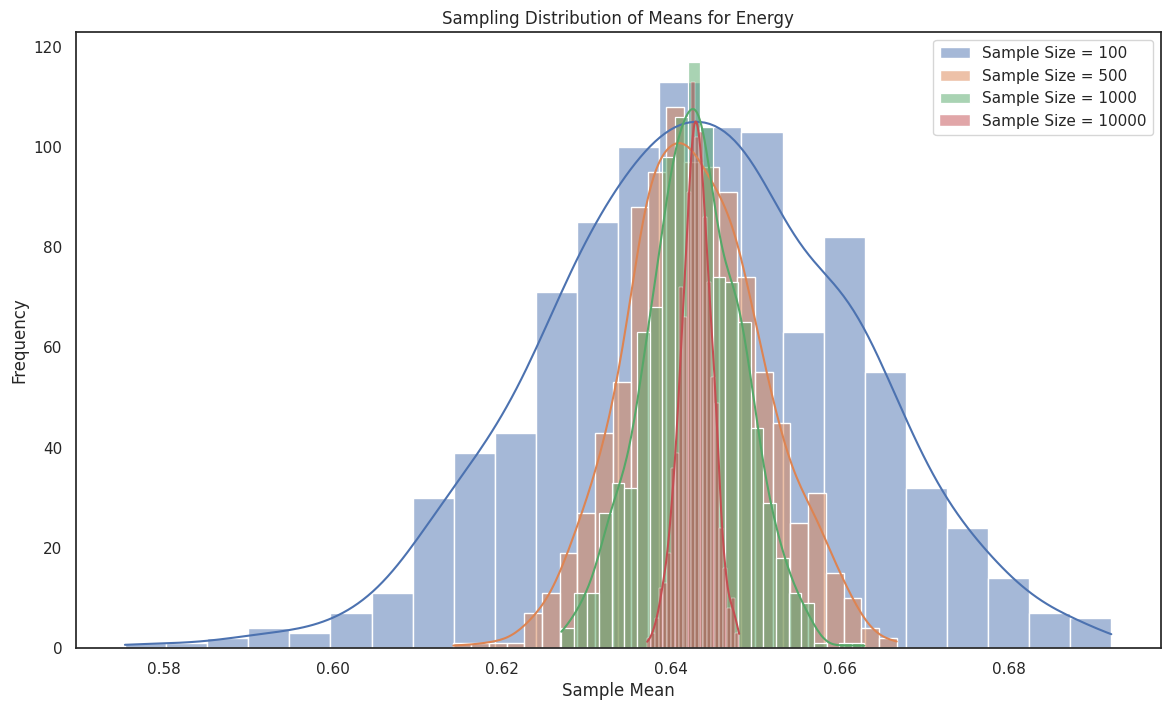

In [ ]:
def plot_sampling_distribution(billboard, column, sample_sizes):
    plt.figure(figsize=(14, 8))
    for size in sample_sizes:
        sample_means = [np.mean(billboard[column].sample(size, replace=True)) for _ in range(1000)]
        sns.histplot(sample_means, kde=True, label=f'Sample Size = {size}')
    plt.title(f'Sampling Distribution of Means for {column}')
    plt.xlabel('Sample Mean')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()


sample_sizes = [100, 500, 1000, 10000]
plot_sampling_distribution(billboard, 'Popularity', sample_sizes)
plot_sampling_distribution(billboard, 'Danceability', sample_sizes)
plot_sampling_distribution(billboard, 'Energy', sample_sizes)

## Confidence Interval

Sample Mean: 67.62
Sample Standard Deviation: 11.36
90% Confidence Interval: 64.98 to 70.26
95% Confidence Interval: 64.47 to 70.77


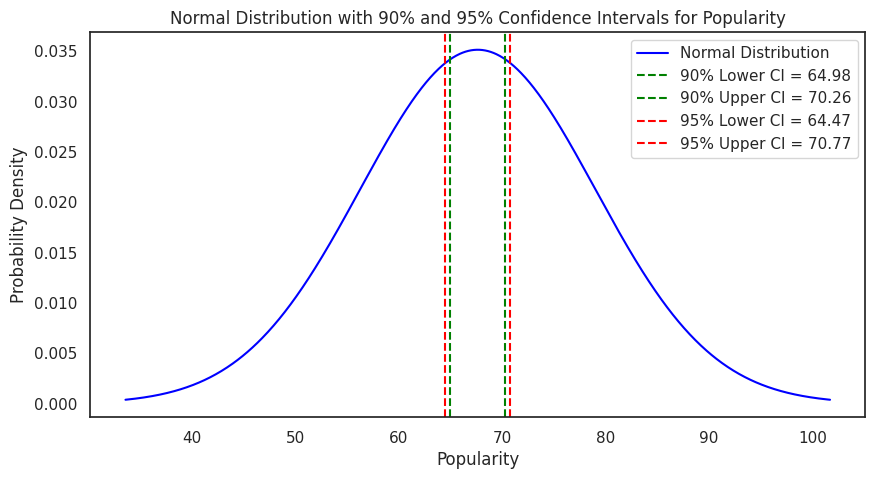

In [ ]:
column = 'Popularity'
sample = billboard[column].dropna().sample(50, random_state=42)

# Calculate sample mean and standard deviation
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)
n = len(sample)

confidence_90 = 0.90
confidence_95 = 0.95

# Z-scores for 90% and 95% confidence levels
z_90 = norm.ppf(1 - (1 - confidence_90) / 2)
z_95 = norm.ppf(1 - (1 - confidence_95) / 2)

# Standard error
std_error = sample_std / np.sqrt(n)

# Confidence interval calculations
CI_90 = (sample_mean - z_90 * std_error, sample_mean + z_90 * std_error)
CI_95 = (sample_mean - z_95 * std_error, sample_mean + z_95 * std_error)

print(f"Sample Mean: {sample_mean:.2f}")
print(f"Sample Standard Deviation: {sample_std:.2f}")
print(f"90% Confidence Interval: {CI_90[0]:.2f} to {CI_90[1]:.2f}")
print(f"95% Confidence Interval: {CI_95[0]:.2f} to {CI_95[1]:.2f}")

# Plotting the distribution and confidence intervals
x_vals = np.linspace(sample_mean - 3*sample_std, sample_mean + 3*sample_std, 1000)
y_vals = norm.pdf(x_vals, sample_mean, sample_std)

plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_vals, label='Normal Distribution', color='blue')

# Plot confidence intervals
plt.axvline(x=CI_90[0], color='green', linestyle='--', label=f'90% Lower CI = {CI_90[0]:.2f}')
plt.axvline(x=CI_90[1], color='green', linestyle='--', label=f'90% Upper CI = {CI_90[1]:.2f}')
plt.axvline(x=CI_95[0], color='red', linestyle='--', label=f'95% Lower CI = {CI_95[0]:.2f}')
plt.axvline(x=CI_95[1], color='red', linestyle='--', label=f'95% Upper CI = {CI_95[1]:.2f}')

plt.title(f'Normal Distribution with 90% and 95% Confidence Intervals for {column}')
plt.xlabel(column)
plt.ylabel('Probability Density')

plt.legend()

plt.show()